# **Sesión 5: Limpieza de datos nulos y duplicados**

## **Objetivo:**
Preparar a los estudiantes con habilidades esenciales para la limpieza de datos nulos y duplicados es un paso crucial en cualquier análisis de datos. Esto incluye la identificación, visualización y tratamiento de valores nulos y duplicados, ya sea mediante la eliminación o imputación, dependiendo del contexto.

---

## **Estructura de la sesión:**

### **1. Datos nulos, clasificación y tratamiento. (20 minutos)**

Es muy importante tratar los valores faltantes en cualquier análisis ya que pueden sesgar los resultados, reducir la precisión de los modelos predictivos y afectar la integridad de los datos.

Cuando manejamos bien los datos faltantes, aseguramos mayor precisión y confiabilidad en los análisis, mejorando la calidad de las decisiones basadas en datos.

#### **1.1 Clasificación**

- **Faltantes completamente al azar (MCAR)**. No hay un patrón por el cual faltan datos en una columna.
  
  - *Ejemplo:* En una encuesta de satisfacción del cliente, algunas respuestas no se tienen porque los encuestados no completaron la encuesta.

    <center>
      <img src="https://static.vecteezy.com/system/resources/previews/008/902/237/non_2x/customer-satisfaction-feedback-scale-emoji-icon-free-vector.jpg"  width="250" />
    </center> 

    **No hay relación entre la falta de respuestas y alguna otra característica de los encuestados ni con otras respuestas en la encuesta**.

  - *Tratamiento:* Se puede usar una imputación de datos simple, rellenando los valores faltantes con la media, mediana o moda de la columna.

- **Faltantes al azar (MAR)**. La razón por la que faltan los datos en una columna puede explicarse por los datos en otras columnas.
  
  - *Ejemplo:* En un estudio médico, los datos de presión arterial pueden faltar para pacientes que no asistieron a sus citas de seguimiento.

    <center>
      <img src="https://t4.ftcdn.net/jpg/01/05/32/45/360_F_105324577_MT73Iu9rmuYeM8H7JFGSlFzsoLlTbGkn.jpg"  width="250" />
    </center> 

    **La ausencia de estos datos puede explicarse por la columna de asistencia a las citas**.

  - *Tratamiento:* Usar técnicas como la imputación por regresión, donde los valores faltantes se predicen usando otras variables en el conjunto de datos. También se pueden usar algoritmos como K-Nearest Neighbors (KNN).

- **Faltantes no al azar (MNAR)**. El valor faltante está relacionado con el valor en sí mismo.
  
  - *Ejemplo:* En una encuesta de ingresos, las personas con ingresos muy altos pueden optar por no revelar sus ingresos.

    <center>
      <img src="https://imageio.forbes.com/specials-images/imageserve/66e6c77631b7fea144aa6136/How-To-Start-A-Passive-Income-Business-With-Little-To-No-Money/960x0.jpg?format=jpg&width=960"  width="250" />
    </center> 

    **La falta de datos está directamente relacionada con el valor en sí mismo, ya que las personas con ingresos altos son más propensas a no divulgar esta información**.

  - *Tratamiento:* Realizar análisis de sensibilidad para evaluar cómo los datos faltantes pueden afectar los resultados y ajustar los modelos en consecuencia.

#### **1.2 Tratamiento**

Una vez que identificamos el motivo por el cuál tenemos datos faltantes y los clasificamos, decidimos como tratarlos.

- **Porcentaje de datos nulos:** Es muy importante considerar esta información para decidir el tratamiento de los datos.
  - <ins>Menos del 5%:</ins> Generalmente, se considera seguro realizar una imputación de los datos faltantes.
  - <ins>Entre el 5% y 20%:</ins> Sigue siendo viable realizar una imputación, pero se debe considerar el impacto potencial sobre los datos.
  - <ins>Más del 20%:</ins> Una imputación puede introducir sesgos significativos, por lo que se podría eliminar la variable en cuestión.

- **Eliminación de registros:** Si los datos faltantes no representan información importante para nuestro análisis.
  
  *Ejemplo:* Queremos analizar la venta promedio por cliente en los diferentes estados, pero encontramos datos faltantes del estado de algunos clientes. Imputar estos datos podría sesgar nuestro análisis, por lo que podríamos eliminar los registros.

- **Imputación:** Las imputaciones de datos dependen del tipo de variables.
  - <ins>Moda:</ins> Utilizado para variables categóricas.
  - <ins>Media:</ins> Utilizado para variables continuas con distribución normal.
  - <ins>Mediana:</ins> Utilizado para variables continuas con distribución no normal.
  - <ins>Basada en modelos:</ins> Utilizado para variables continuas (Regresión, K-Nearest Neighbors).

- **Eliminación de variable:** Cuando la variable no agrega valor al análisis en cuestión o cuando el porcentaje de datos faltantes excede el 20%.

### **2. "Game On!" Datos Faltantes . (25 minutos)**

**Ejercicio guiado:**

**Caso:** *Game ON!* una empresa pequeña de video juegos nos pidio analizar la satisfacción de sus clientes basado en una encuesta que mando a sus clientes.

<center>
        <img src="https://media.licdn.com/dms/image/C4D12AQF43ifDqHuAHQ/article-cover_image-shrink_600_2000/0/1567815408502?e=2147483647&v=beta&t=6QaRQ9mqeXVAQhMYm0MxYfejpSimksbaXk8s1EKTDqs"  width="400" />
      </center> 

  **Registros:** 
  
  Se tiene la información de 188 clientes.
  
  **Variables:**

  - *Id:* Número de identificación de cada clientes.
  - *Edad.*
  - *Género:* (Hombre/Mujer)
  - *Encuesta:* Variable binaria que indica si el cliente contesto la encuenta o no (1=Sí / 0= No).
  - *Satisfacción:* Calificación de experiencia del cliente (1:Muy Mala - 5:Muy Buena).
  - *Compra:* Monto de las compras que el cliente ha realizado (USD).
  - *Artículos:* Número de articulos que el cliente ha comprado.

**Análisis datos faltantes**.

In [3]:
import pandas as pd

games = pd.read_csv('data/videogames_data.csv')

In [3]:
games.head()

,id,edad,genero,encuesta,satisfaccion,compra,articulos
0,1,25.5,Hombre,1,2.0,206.3,4.0
1,2,40.0,Hombre,1,5.0,297.9,NaN
2,3,30.0,Hombre,1,3.0,273.4,NaN
3,4,29.5,Mujer,1,5.0,327.6,NaN
4,5,35.0,Hombre,0,NaN,509.7,4.0


In [4]:
#Obtenemos el numero de datos no nulos y el tipo de dato
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            188 non-null    int64  
 1   edad          175 non-null    float64
 2   genero        164 non-null    object 
 3   encuesta      188 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        150 non-null    float64
 6   articulos     114 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 10.4+ KB


Número de datos nulos

In [7]:
games.isnull().sum()

id               0
edad            13
genero          24
encuesta         0
satisfaccion    43
compra          38
articulos       74
dtype: int64

Número de datos no nulos

In [9]:
games.notnull().sum()

id              188
edad            175
genero          164
encuesta        188
satisfaccion    145
compra          150
articulos       114
dtype: int64

Porcentaje de nulos

In [12]:
games.isnull().sum()/len(games)

id              0.000000
edad            0.069149
genero          0.127660
encuesta        0.000000
satisfaccion    0.228723
compra          0.202128
articulos       0.393617
dtype: float64

- *Edad:* 13 de 188 registros (6.9%). | Completamente al azar 
- *Género:* 24 de 188 registros (12.7%). | Completamente al azar 
- *Satisfacción:* 43 de 188 registros(22.9%). | Al azar o No Al Azar
- *Compra:* 38 de 188 registros (20.2%). | Completamente al azar 
- *Artículos:* 74 de 188 registros (39.3%). | Completamente al azar 

**Eliminación de datos faltantes**

Los clientes que tiene datos faltantes en la variable *satisfacción*, es debido a que no contestaron la encuesta. Como el objetivo principal es sobre aquellos que sí la realizaron, se eliminaran esos datos nulos. 

**NOTA:** Este tipo de decisiones puede llevarte a un sesgo de selección. (Fun fact)

In [14]:
games.dropna(subset=['satisfaccion'], inplace=True)

In [16]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 187
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            145 non-null    int64  
 1   edad          134 non-null    float64
 2   genero        127 non-null    object 
 3   encuesta      145 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        132 non-null    float64
 6   articulos     88 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 9.1+ KB


Revisamos los datos faltantes de nuevo

In [18]:
games.isnull().sum()

id               0
edad            11
genero          18
encuesta         0
satisfaccion     0
compra          13
articulos       57
dtype: int64

In [20]:
games.isnull().sum()/len(games)

id              0.000000
edad            0.075862
genero          0.124138
encuesta        0.000000
satisfaccion    0.000000
compra          0.089655
articulos       0.393103
dtype: float64

In [22]:
games.head()

,id,edad,genero,encuesta,satisfaccion,compra,articulos
0,1,25.5,Hombre,1,2.0,206.3,4.0
1,2,40.0,Hombre,1,5.0,297.9,NaN
2,3,30.0,Hombre,1,3.0,273.4,NaN
3,4,29.5,Mujer,1,5.0,327.6,NaN
7,8,34.5,Hombre,1,3.0,152.6,4.0


**Imputación por moda**

La variable *género* esta dentro de los limites aceptable para realizar una imputación de datos, al ser una variable categórica se hara por moda. 

In [40]:
games['genero'].value_counts()

genero
Hombre    73
Mujer     54
Name: count, dtype: int64

In [38]:
games['genero'].mode()[0]

'Hombre'

Rellenamos la variable género

In [42]:
games.fillna({'genero': games['genero'].mode()[0]}, inplace=True)

Checamos porcentaje de NULLs

In [44]:
games.isnull().sum()/len(games)

id              0.000000
edad            0.075862
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.089655
articulos       0.393103
dtype: float64

**Imputación por media**

La variable *edad* esta dentro de los limites aceptable para realizar una imputación de datos.  

¿Qué distribución tiene?

<Axes: >

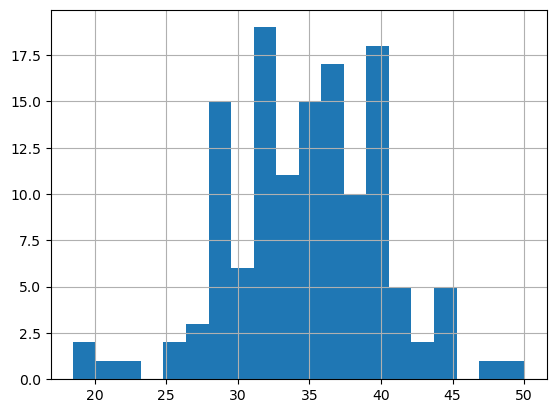

In [46]:
games['edad'].hist(bins=20)

Por ser distribución normal imputaremos la media. 

In [48]:
games.fillna({'edad': games['edad'].mean()}, inplace=True)

In [50]:
games.isnull().sum()/len(games)

id              0.000000
edad            0.000000
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.089655
articulos       0.393103
dtype: float64

**Imputación por mediana**

La variable *compra* esta dentro de los limites aceptable para realizar una imputación de datos. 

Checamos la distribución. 

<Axes: >

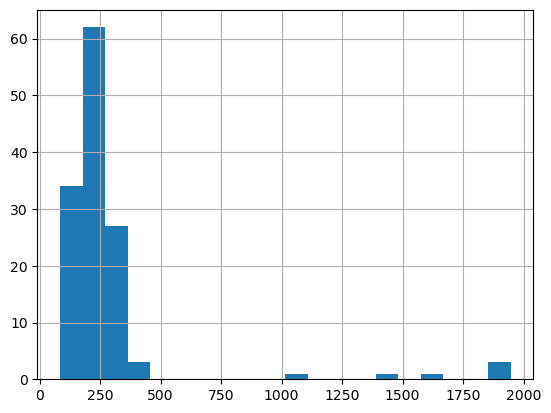

In [52]:
games['compra'].hist(bins=20)

Hace más sentido una imputación de mediana. 

In [54]:
games.fillna({'compra': games['compra'].median()}, inplace=True)

In [56]:
games.isnull().sum()/len(games)

id              0.000000
edad            0.000000
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.000000
articulos       0.393103
dtype: float64

**Eliminación de variable**

La variable *artículos* no está dentro de los limites aceptable para realizar una imputación de datos, al tener 39.3% de los datos con datos faltantes, se elimina del dataset para no generar sesgo.

In [58]:
games = games.drop(columns=['articulos'])
games.head()

,id,edad,genero,encuesta,satisfaccion,compra
0,1,25.5,Hombre,1,2.0,206.3
1,2,40.0,Hombre,1,5.0,297.9
2,3,30.0,Hombre,1,3.0,273.4
3,4,29.5,Mujer,1,5.0,327.6
7,8,34.5,Hombre,1,3.0,152.6


In [60]:
games.isnull().sum()/len(games)

id              0.0
edad            0.0
genero          0.0
encuesta        0.0
satisfaccion    0.0
compra          0.0
dtype: float64

### **3. "Elite Properties" Datos Faltante (30 minutos)**

**Ejercicios de los estudiantes:**

**Caso:** *Elite Properties*, una empresa inmobiliaria australiana identificó que, en el último año, la venta de casas en el área de Melbourne ha experimentado un auge. Melbourne se encuentra en el estado de Victoria. La empresa recopiló información sobre diferentes casas en venta en diferentes áreas de Victoria durante el último trimestre del 2024 .

El equipo de análisis de la empresa utilizará esta información para evaluar la conveniencia de invertir en alguna área específica.

<center>
        <img src="https://img.freepik.com/premium-vector/people-buying-house-concept-man-woman-with-magnifying-glass-evaluate-real-estate-private-property-savings-family-budget-economics-investment-cartoon-flat-vector-illustration_118813-15861.jpg?semt=ais_hybrid"  width="250" />
      </center> 

  **Registros:** 
  
  Se tiene la información de 7,559 viviendas.

  **Variables**

  - *Área:* Área dentro del estado de Victoria donde se encuentra la casa.
  - *Dirección.*
  - *Código Postal.*
  - *Fecha:* Fecha en la que se pusó en venta la casa.
  - *Precio:* En dólares
  - *Habitaciones:* Número de cuartos.
  - *Distancia:* Distancia desde el distrito central de negocios (Kilometros).
  - *Baños:* Número de baños completos.
  - *Carros:* Numero de espacio de estacionamiento.
  - *Terreno:* Metros cuadrados de terreno.
  - *Construcción:* Metros cuadrados de espacio construido.
  - *Año de Construcción.*



In [1]:
import pandas as pd

In [3]:
houses = pd.read_csv('data/houses_data.csv')

- Chequen las columnas y tipos de datos de su dataset

In [6]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7559 entries, 0 to 7558
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             6856 non-null   object 
 1   Direccion        7559 non-null   object 
 2   CodigoPostal     7559 non-null   int64  
 3   Fecha            6520 non-null   object 
 4   Precio           6830 non-null   float64
 5   Habitaciones     7559 non-null   int64  
 6   Distacia         7559 non-null   float64
 7   Banos            7559 non-null   int64  
 8   Carros           7527 non-null   float64
 9   Terreno          7559 non-null   int64  
 10  Construccion     7129 non-null   float64
 11  AnoConstriccion  5074 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 708.8+ KB


In [8]:
houses.head()

,Area,Direccion,CodigoPostal,Fecha,Precio,Habitaciones,Distacia,Banos,Carros,Terreno,Construccion,AnoConstriccion
0,Yarra,25 Bloomburg St,3067,11/1/2024,1035000.0,2,2.5,1,0.0,156,79.0,NaN
1,Yarra,5 Charles St,3067,10/1/2024,1465000.0,3,2.5,2,0.0,134,150.0,NaN
2,Yarra,55a Park St,3067,12/1/2024,1600000.0,4,2.5,1,2.0,120,142.0,2014.0
3,Yarra,124 Yarra St,3067,NaN,1876000.0,3,2.5,2,0.0,245,210.0,NaN
4,Yarra,98 Charles St,3067,12/1/2024,1636000.0,2,2.5,1,2.0,256,107.0,NaN


- Obtengan proporción de nulos por columna.

In [11]:
houses.isnull().sum()

Area                703
Direccion             0
CodigoPostal          0
Fecha              1039
Precio              729
Habitaciones          0
Distacia              0
Banos                 0
Carros               32
Terreno               0
Construccion        430
AnoConstriccion    2485
dtype: int64

In [13]:
houses.isnull().sum() / len(houses)

Area               0.093002
Direccion          0.000000
CodigoPostal       0.000000
Fecha              0.137452
Precio             0.096441
Habitaciones       0.000000
Distacia           0.000000
Banos              0.000000
Carros             0.004233
Terreno            0.000000
Construccion       0.056886
AnoConstriccion    0.328747
dtype: float64

Como primer paso analizamos las variables en las que tenemos datos faltantes:

- *Área:* `?` de 7,559 registros (`?`%).
- *Fecha:* `?` de 7,559 registros (`?`%). 
- *Precio:* `?` de 7,559 registros(`?`%).
- *Carros:* `?` de 7,559 registros (`?`%).
- *Construcción:* `?` de 7,559 registros (`?`%).
- *Año Construcción:* `?` de 7,559 registros (`?`%).

El análisis solicitado es para analizar si es conveniente invertir en algun **área especifica de Victoria**, por lo tanto los el área y el precio de las casas son **cruciales** para realizarlo.

**Se decide eliminar los registros con datos faltantes en área y precio.**

- Eliminar las **filas con datos faltantes en Área y Precio**

In [15]:
houses.dropna(subset=['Area','Precio'], inplace=True)

Decreció el tamaño del dataset, se tiraron las filas con valores faltantes en esas columnas. 

In [17]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6187 entries, 0 to 6855
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             6187 non-null   object 
 1   Direccion        6187 non-null   object 
 2   CodigoPostal     6187 non-null   int64  
 3   Fecha            5325 non-null   object 
 4   Precio           6187 non-null   float64
 5   Habitaciones     6187 non-null   int64  
 6   Distacia         6187 non-null   float64
 7   Banos            6187 non-null   int64  
 8   Carros           6187 non-null   float64
 9   Terreno          6187 non-null   int64  
 10  Construccion     5823 non-null   float64
 11  AnoConstriccion  4109 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 628.4+ KB


- Observamos la nueva proporción de NULLs.

In [23]:
houses.isnull().sum()

Area                  0
Direccion             0
CodigoPostal          0
Fecha               862
Precio                0
Habitaciones          0
Distacia              0
Banos                 0
Carros                0
Terreno               0
Construccion        364
AnoConstriccion    2078
dtype: int64

In [25]:
houses.isnull().sum() / len(houses)

Area               0.000000
Direccion          0.000000
CodigoPostal       0.000000
Fecha              0.139324
Precio             0.000000
Habitaciones       0.000000
Distacia           0.000000
Banos              0.000000
Carros             0.000000
Terreno            0.000000
Construccion       0.058833
AnoConstriccion    0.335866
dtype: float64

Se vuelven a analizar las variables en las que tenemos datos faltantes:

- Con la eliminación de datos faltantes en las variables de **Área** y **Precio** se reducen los registros de `X` a `Z`. 
- La variable Carros ya no contiene datos faltantes al realizar la eliminación de duplicados anterior.

    - *Fecha:* `?` de `Z` registros (`?`%). 
    - *Construcción:* `?` de `Z` registros (`?`%).
    - *Año Construcción:* `?` de `Z` registros (`?`%).

- ¿Qué hacemos con estas variables?

**La variable Construcción** nos indica el tamaño de la propiedad y se considera importante, **se decide realizar una imputacion de los datos.**

Para realizar la imputacion revisaremos como se distribuyen los datos:

- Distribución normal (imputación por media).
- Distribución no normal (imputación por mediana). 

- Checamos el grado de asimetría con `skew`.

In [26]:
houses['Construccion'].skew()

2.730084146613284

In [27]:
import matplotlib.pyplot as plt

- Hacemos su histograma.

<Axes: >

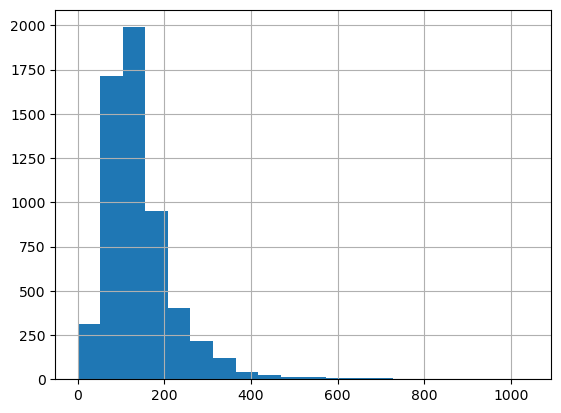

In [30]:
houses['Construccion'].hist(bins=20)

In [32]:
houses['Construccion'].mean()

142.82259723510217

- Imputamos.

In [34]:
houses['Construccion'].fillna(houses['Construccion'].median(), inplace=True)

/var/folders/5_/9lpts4396xlf9_gxc7xwyx140000gn/T/ipykernel_96683/577151731.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  houses['Construccion'].fillna(houses['Construccion'].median(), inplace=True)


In [36]:
houses.notnull().sum() / len(houses)*100

Area               100.000000
Direccion          100.000000
CodigoPostal       100.000000
Fecha               86.067561
Precio             100.000000
Habitaciones       100.000000
Distacia           100.000000
Banos              100.000000
Carros             100.000000
Terreno            100.000000
Construccion       100.000000
AnoConstriccion     66.413448
dtype: float64

### **4. Datos duplicados. (15 minutos)**

Cuando trabajamos con datos podemos encontrar o crear dataset con datos repetidos, esto puede ser de manera intencional o no intencional. Es importante realizar un análisis y tratarlo de manera correcta, esto puede impactar en los resultados finales y toma de decisiones.

El primer paso a realizar cuando analizamos los datos duplicados es entender y tracker el **por qué** nuestro dataset contiene estos valores.

- Error humano
    - Ingreso de los datos
    - Data Wranwling (Unir dataset)
- Valores con idenficador igual pero valores diferentes en otras variables.
    - *Ejemplo:* 2 registros, mismo cliente, mismo mes de compra, tipo compra diferente (linea / persona), cantidad gastada diferente.

    <center>
      <img src="https://www.blastanalytics.com/wp-content/uploads/2022/08/Analytics-Wants-vs-Analytics-Needs_Illustration-6-1920x609.png"  width="450" />
    </center> 

In [38]:
games_dup = pd.read_csv('data/videogames_data_dup.csv')

- Vemos el dataset. 

In [40]:
games_dup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            126 non-null    int64  
 1   edad          126 non-null    float64
 2   genero        126 non-null    object 
 3   encuesta      126 non-null    int64  
 4   satisfaccion  126 non-null    int64  
 5   compra        126 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 6.0+ KB


- `duplicated` va a retornarte una `Serie` donde marca como `True` los registros duplicados **excepto** el primer registro encontrado. 

In [42]:
games_dup.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
121     True
122    False
123    False
124    False
125    False
Length: 126, dtype: bool

In [44]:
games_dup.duplicated().sum()

17

- Todos estos registros están duplicados. 

In [46]:
games_dup[games_dup.duplicated()]

,id,edad,genero,encuesta,satisfaccion,compra
105,1,25.5,Hombre,1,2,206.3
106,2,40.0,Hombre,1,5,297.9
107,3,30.0,Hombre,1,3,273.4
108,4,29.5,Mujer,1,5,327.6
109,8,34.5,Hombre,1,3,152.6
110,9,36.5,Mujer,1,5,276.5
111,12,35.0,Mujer,1,1,93.1
112,13,32.0,Hombre,1,5,136.3
113,17,28.5,Mujer,1,3,204.8
114,19,36.5,Mujer,1,5,337.7


In [48]:
games_dup[games_dup['id']==1]

,id,edad,genero,encuesta,satisfaccion,compra
0,1,25.5,Hombre,1,2,206.3
105,1,25.5,Hombre,1,2,206.3


¿Por qué tenemos duplicados?

Revisamos con la empresa y nos contaron que identificaron que exactamente 17 clientes contestaron 2 veces la encuesta. Por lo tanto podemos **eliminar los registros duplicados**.

In [50]:
#Mantiene el primer registro
games_dup.drop_duplicates(inplace=True)

In [52]:
#check duplicados
games_dup.duplicated().sum()

0

**Registros con algunos valores iguales**

Sabemos que por la naturaleza de nuestro dataset solo deemos tener un registro por clientes. Una vez que borramos los registros exactamente iguales, revisamos que esta regla sea cierta.

In [56]:
games_dup.duplicated(subset=['id'])

0      False
1      False
2      False
3      False
4      False
       ...  
104    False
122     True
123     True
124     True
125     True
Length: 109, dtype: bool

In [58]:
games_dup[games_dup.duplicated(subset=['id'])]

,id,edad,genero,encuesta,satisfaccion,compra
122,120,29.0,Hombre,1,2,768.5
123,123,40.5,Hombre,1,3,456.8
124,125,35.0,Hombre,1,4,190.5
125,126,35.5,Hombre,1,2,867.5


In [60]:
duplicated_ids = games_dup[games_dup.duplicated(subset=['id'])]['id']

In [66]:
games_dup[games_dup['id'].isin([120,123,125,126])]

,id,edad,genero,encuesta,satisfaccion,compra
55,120,29.0,Hombre,1,2,162.7
56,123,40.5,Hombre,1,3,207.1
57,125,35.0,Hombre,1,4,156.9
58,126,35.5,Hombre,1,2,181.7
122,120,29.0,Hombre,1,2,768.5
123,123,40.5,Hombre,1,3,456.8
124,125,35.0,Hombre,1,4,190.5
125,126,35.5,Hombre,1,2,867.5


Identificamos que se tiene el registro de 4 clientes duplicados, observamos que el monto de compra es diferente para cada cliente duplicado. 

Al no saber la razón por la cual este valor es diferente, no podemos decidir cual registro mantener o incluso podemos sospechar sobre la calidad de los datos. Debemos trackaer si algún momento de la creación del dataset se generó a esta duplicación.

### **5. Conclusiones y cierre (10 minutos)**

### **Reflexión final**
- Explicar la importancia de hacer una limpieza correcta de los datos nulos y duplicados.  
- Enfatizar por qué el contexto de los datos y análisis son clave para decidir el tratamiento.  
- Relacionar esta actividad con los retos que se enfrentan en el mundo de datos.